<a href="https://colab.research.google.com/github/weagan/Energy-Based-Models-Predictive-Coding/blob/main/Predictive_coding_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [ ]:
class PredictiveCodingNetwork(nn.Module):
    def __init__(self, visible_dim, hidden_dim):
        super(PredictiveCodingNetwork, self).__init__()
        # Top-down weights: Generating visible from hidden
        self.W_td = nn.Parameter(torch.randn(visible_dim, hidden_dim) * 0.01) # Corrected: visible_dim, hidden_dim
        # Top-down biases
        self.b_td = nn.Parameter(torch.zeros(visible_dim))
        # Bottom-up weights: Inferring hidden from visible
        self.W_bu = nn.Parameter(torch.randn(hidden_dim, visible_dim) * 0.01)
        # Bottom-up biases
        self.b_bu = nn.Parameter(torch.zeros(hidden_dim))

    def forward(self, v0):
        # v0: Input data (Batch, Visible)
        # Compute bottom-up representation (State of hidden layer)
        h0 = torch.sigmoid(F.linear(v0, self.W_bu, self.b_bu))

        # Compute top-down prediction (Reconstruction)
        v_pred = torch.sigmoid(F.linear(h0, self.W_td, self.b_td))

        return v_pred, h0

    def sample(self, h, steps=10):
        """Generate data by iteratively predicting and updating states."""
        v = torch.sigmoid(F.linear(h, self.W_td, self.b_td))
        for _ in range(steps):
            h = torch.sigmoid(F.linear(v, self.W_bu, self.b_bu))
            v = torch.sigmoid(F.linear(h, self.W_td, self.b_td))
        return v

In [ ]:
def pc_loss(v0, v_pred, h0, W_bu, b_bu):
    """
    Predictive Coding Loss (Global Energy):
    1. Reconstruction Error (Minimizing difference between data and top-down prediction)
    2. Sparsity/Regularization on the hidden states
    """
    # Visible prediction error (Mean Squared Error)
    epsilon_v = F.mse_loss(v_pred, v0, reduction='sum') / v0.size(0)

    # Hidden state prior (Encourage sparse binary-like hidden states)
    # KL divergence from a uniform Bernoulli prior (p=0.5)
    eps = 1e-8
    kl_div = -0.5 * (torch.log(h0 + eps) + torch.log(1 - h0 + eps)).sum(1).mean()

    return epsilon_v + 0.01 * kl_div

In [ ]:
# Hyperparameters
batch_size = 64
visible_dim = 28 * 28
hidden_dim = 256
epochs = 15
lr = 0.01

# Load MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1)) # Flatten to 784
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Initialize model
model = PredictiveCodingNetwork(visible_dim, hidden_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

Epoch [1/15], Energy (Loss): 12.6377
Epoch [2/15], Energy (Loss): 5.1324
Epoch [3/15], Energy (Loss): 4.2817
Epoch [4/15], Energy (Loss): 3.9290
Epoch [5/15], Energy (Loss): 3.7517
Epoch [6/15], Energy (Loss): 3.6365
Epoch [7/15], Energy (Loss): 3.5616
Epoch [8/15], Energy (Loss): 3.5455
Epoch [9/15], Energy (Loss): 3.4793
Epoch [10/15], Energy (Loss): 3.4925
Epoch [11/15], Energy (Loss): 3.4689
Epoch [12/15], Energy (Loss): 3.4508
Epoch [13/15], Energy (Loss): 3.4408
Epoch [14/15], Energy (Loss): 3.4485
Epoch [15/15], Energy (Loss): 3.4418


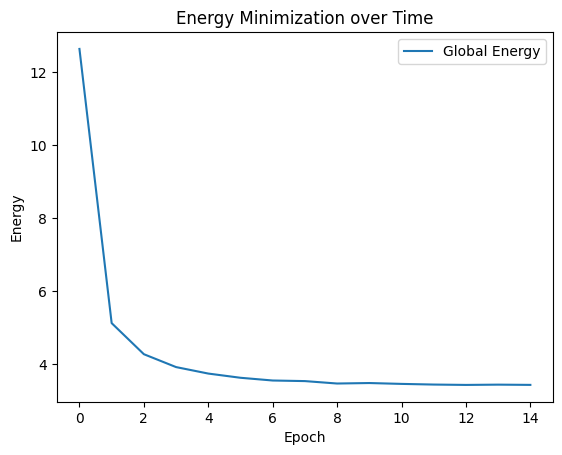

In [ ]:
model.train()
loss_history = []

for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)

        # 1. Bottom-up inference (Get hidden states)
        v_pred, h0 = model(data)

        # 2. Calculate Prediction Errors
        loss = pc_loss(data, v_pred, h0, model.W_bu, model.b_bu)

        # 3. Update Synapses (Minimize Energy)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}], Energy (Loss): {avg_loss:.4f}")

plt.plot(loss_history, label='Global Energy')
plt.title('Energy Minimization over Time')
plt.xlabel('Epoch')
plt.ylabel('Energy')
plt.legend()
plt.show()

<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_17775/736198258.py:24: SyntaxWarning: invalid escape sequence '\m'
  axes[1, i].set_title('Top-Down Prediction ($\mu_v$)')


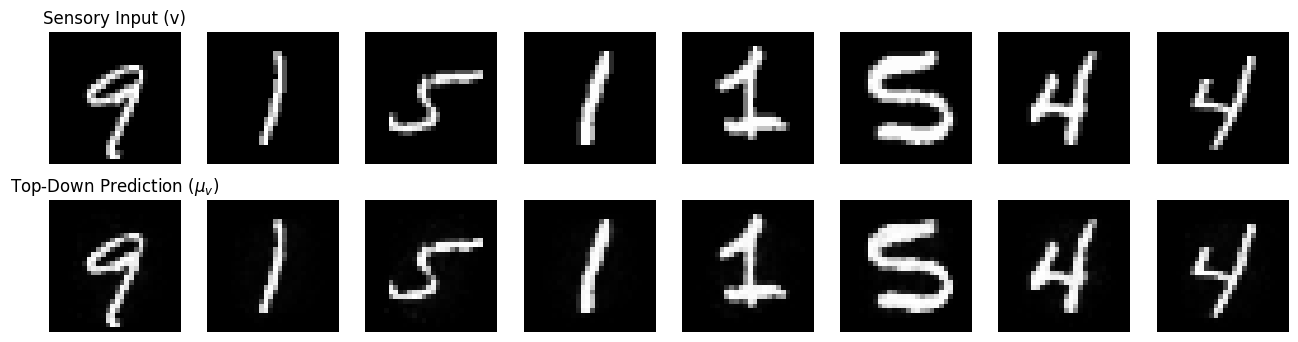

In [ ]:
def visualize_predictions(model, loader, num_images=8):
    model.eval()
    with torch.no_grad():
        # Get a batch of data
        data, _ = next(iter(loader))
        data = data.to(device)

        # Get top-down predictions
        v_pred, _ = model(data)

        # Plot
        fig, axes = plt.subplots(2, num_images, figsize=(16, 4))
        for i in range(num_images):
            # Original
            axes[0, i].imshow(data[i].cpu().view(28, 28).numpy(), cmap='gray')
            axes[0, i].axis('off')
            if i == 0:
                axes[0, i].set_title('Sensory Input (v)')

            # Top-down Prediction
            axes[1, i].imshow(v_pred[i].cpu().view(28, 28).numpy(), cmap='gray')
            axes[1, i].axis('off')
            if i == 0:
                axes[1, i].set_title('Top-Down Prediction ($\mu_v$)')
        plt.show()

visualize_predictions(model, train_loader)

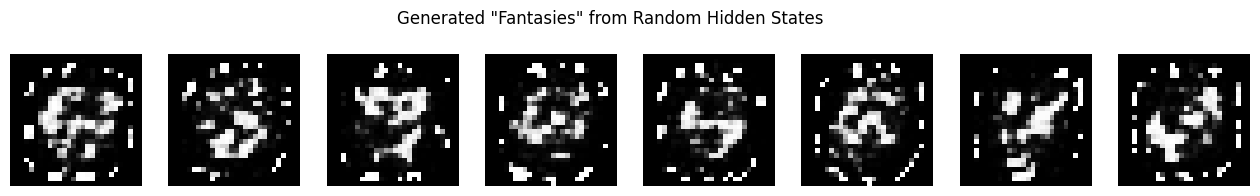

In [ ]:
def generate_samples(model, num_samples=8, gibbs_steps=50):
    model.eval()
    with torch.no_grad():
        # Start with random hidden states (Neural "idea" or "prior")
        h = torch.randn(num_samples, hidden_dim).to(device)

        # Iterative Predictive Coding loop
        for step in range(gibbs_steps):
            v = torch.sigmoid(F.linear(h, model.W_td, model.b_td))
            h = torch.sigmoid(F.linear(v, model.W_bu, model.b_bu))

        fig, axes = plt.subplots(1, num_samples, figsize=(16, 2))
        for i in range(num_samples):
            axes[i].imshow(v[i].cpu().view(28, 28).numpy(), cmap='gray')
            axes[i].axis('off')
        plt.suptitle('Generated "Fantasies" from Random Hidden States', y=1.05)
        plt.show()

generate_samples(model)